# Lab 1: EM algorithm and Gaussian mixture model

## Introduction to Statistical Estimation, Centrale Lille

The goal of this lab is to implement the EM algorithm to estimate, by maximum likelihood, the parameters of a Gaussian mixture model.

We use the *Old Faithful* dataset, which describes 272 eruptions of the Old Faithful geyser in Yellowstone National Park, United States. Each observation has 2 variables: the eruption duration (in minutes) and the waiting time before the eruption (in minutes).

**Report by Ugo Roccamatisi.**


In [1]:
# Import necessary libraries
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

**Q1**. Load the dataset, standardize it, then visualize the data. Comment.

Shape: (272, 2) means: [4.84906233e-16 4.40823848e-16] standard deviations: [1. 1.]


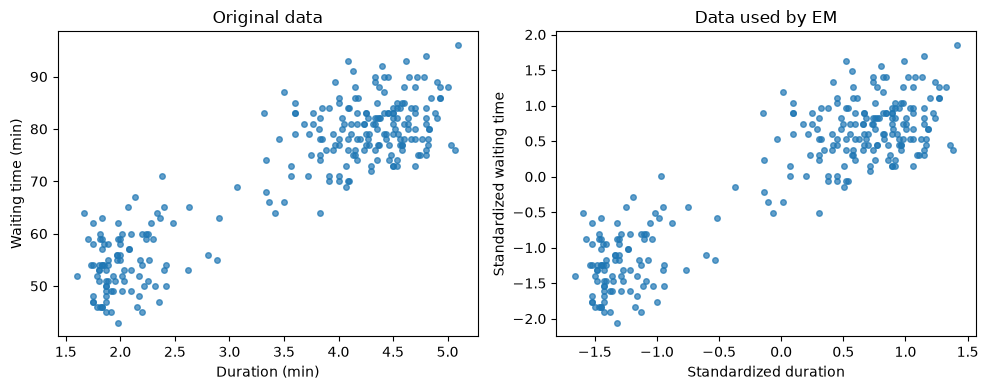

In [2]:
from pathlib import Path
# The columns are the duration (min) and the waiting time (min).
X_original=np.load(Path('oldfaithful.npy'))
mean_X=X_original.mean(axis=0);std_X=X_original.std(axis=0)
X=(X_original-mean_X)/std_X  # Column-wise standardization.
print('Shape:',X.shape,'means:',X.mean(axis=0),'standard deviations:',X.std(axis=0))
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(*X_original.T,s=16,alpha=.7);axes[0].set(xlabel='Duration (min)',ylabel='Waiting time (min)',title='Original data')
axes[1].scatter(*X.T,s=16,alpha=.7);axes[1].set(xlabel='Standardized duration',ylabel='Standardized waiting time',title='Data used by EM')
fig.tight_layout();plt.show()

**Answer.** Standardization puts duration and waiting time on comparable scales. The point cloud shows two high-density regions, which suggests trying at least two components.

**Q2**. Let $\mathbf{x}_1,...,\mathbf{x}_n$ denote the data. We want to model them with a Gaussian mixture model with $K$ components.

Write a function that computes the log-likelihood:
$$ \log \mathcal{L}(\theta;\mathbf{x}_1,...,\mathbf{x}_n) = \sum_{i=1}^n \log \left( \sum_{k=1}^K \pi_k \frac{1}{2 \pi \text{det}(\boldsymbol{\Sigma}_k)^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x}_i - \boldsymbol{\mu}_k)^{\top} \boldsymbol{\Sigma}_k^{-1} (\mathbf{x}_i - \boldsymbol{\mu}_k) \right) \right), $$
with $\theta = \{ \boldsymbol{\mu_1}, ..., \boldsymbol{\mu_K}, \boldsymbol{\Sigma}_1, ..., \boldsymbol{\Sigma}_K, \pi_1, ..., \pi_K \}$.

The `multivariate_normal.pdf` function from scipy.stats can be used.

In [3]:
from scipy.special import logsumexp

def component_log_prob(X,mu,cov,p):
    """log[pi_k N(x_i|mu_k,Sigma_k)]: n × K matrix."""
    return np.column_stack([np.log(p[k])+ss.multivariate_normal.logpdf(X,mean=mu[k],cov=cov[k]) for k in range(len(p))])

def log_likelihood(X,mu,cov,p):
    # logsumexp avoids underflow of very small densities.
    return float(np.sum(logsumexp(component_log_prob(X,mu,cov,p),axis=1)))

# Note: the exponent of the normal density in the original handout was missing its MINUS SIGN (corrected above).

**Q3**. Write a function implementing the EM algorithm for this model, taking as arguments the data, the number of components $K$ and the number of iterations $N_{\text{iter}}$. The function returns an array of size $N_{\text{iter}} + 1$ with the evolution of the log-likelihood, together with the final parameter values.

Parameter initialization:
- Means: the first $K$ observations of the dataset;
- Covariance matrices: the identity matrix;
- $\pi_k = 1/K$ for all $k$.

In [4]:
def em_from_initialization(X,mu,cov,p,Niter,min_covar=1e-5):
    """One E step (responsibilities) then one M step (parameters); history of length n_iter+1."""
    n,d=X.shape;K=len(p)
    history=np.empty(Niter+1);history[0]=log_likelihood(X,mu,cov,p)
    for i in range(Niter):
        # E step: r_ik = P(Z_i=k | x_i, theta).
        weighted_log=component_log_prob(X,mu,cov,p)
        responsibility=np.exp(weighted_log-logsumexp(weighted_log,axis=1,keepdims=True))
        # M step: weighted mean of each latent group.
        Nk=responsibility.sum(axis=0)
        if np.any(Nk<1e-10):
            raise RuntimeError('Empty component: restart with another initialization')
        p=Nk/n
        mu=responsibility.T@X/Nk[:,None]
        centered=X[:,None,:]-mu[None,:,:]
        cov=np.einsum('nk,nki,nkj->kij',responsibility,centered,centered)/Nk[:,None,None]
        # Very light regularization: guarantees invertible covariances.
        cov+=min_covar*np.eye(d)[None,:,:]
        history[i+1]=log_likelihood(X,mu,cov,p)
    return history,mu,cov,p

def EM_algorithm_v1(X,K,Niter):
    n,d=X.shape
    if not 1<=K<=n:raise ValueError('K must be between 1 and n')
    mu=X[:K].copy();cov=np.repeat(np.eye(d)[None,:,:],K,axis=0)
    p=np.full(K,1/K)
    return em_from_initialization(X,mu,cov,p,Niter)

**Q4**. Run the algorithm with $K = 2$ and $N_{\text{iter}} = 50$.

Plot the log-likelihood as a function of the iterations. Comment.

On a single figure, plot the dataset and show the two estimated normal components of the mixture with a *contour plot*. The `plt.contour` function can be used (see for example [here](https://gist.github.com/gwgundersen/90dfa64ca29aa8c3833dbc6b03de44be)).

Initial/final log-likelihood: -745.817 -385.461
Weights: [0.644 0.356] standardized centers:
 [[ 0.704  0.668]
 [-1.274 -1.21 ]]
Largest decrease (numerical tolerance): -1.1368683772161603e-13


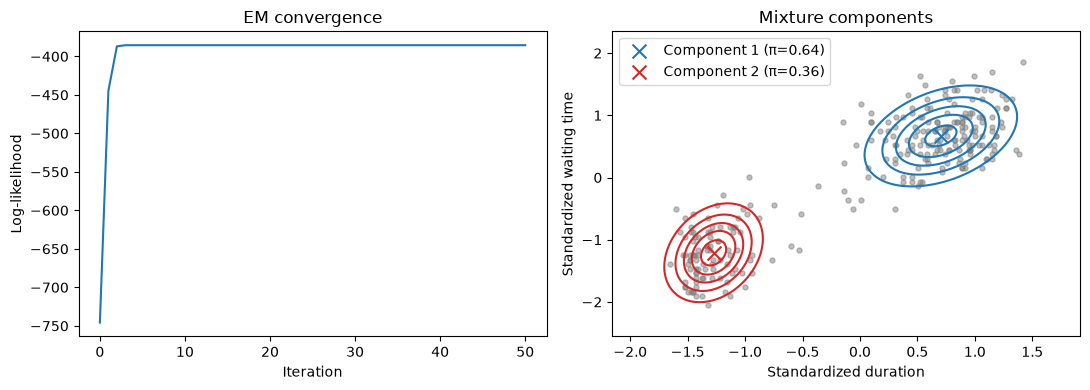

In [5]:
K=2;Niter=50
ll2,mu2,cov2,p2=EM_algorithm_v1(X,K,Niter)
print('Initial/final log-likelihood:',round(ll2[0],3),round(ll2[-1],3))
print('Weights:',np.round(p2,3),'standardized centers:\n',np.round(mu2,3))
print('Largest decrease (numerical tolerance):',np.diff(ll2).min())
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(np.arange(Niter+1),ll2);axes[0].set(xlabel='Iteration',ylabel='Log-likelihood',title='EM convergence')
axes[1].scatter(*X.T,s=13,c='gray',alpha=.5)
xx,yy=np.meshgrid(np.linspace(X[:,0].min()-.5,X[:,0].max()+.5,160),np.linspace(X[:,1].min()-.5,X[:,1].max()+.5,160))
grid=np.c_[xx.ravel(),yy.ravel()]
for k,color in enumerate(['tab:blue','tab:red']):
    dens=ss.multivariate_normal.pdf(grid,mu2[k],cov2[k]).reshape(xx.shape)
    axes[1].contour(xx,yy,dens,levels=5,colors=color)
    axes[1].scatter(*mu2[k],c=color,marker='x',s=100,label=f'Component {k+1} (π={p2[k]:.2f})')
axes[1].legend();axes[1].set(xlabel='Standardized duration',ylabel='Standardized waiting time',title='Mixture components')
fig.tight_layout();plt.show()

**Answer.** For K=2, the log-likelihood rises from −745.817 to −385.461 and then stabilizes. The two estimated weights are 0.644 and 0.356, and the centers sit in the two clusters of the point cloud. The smallest decrease in the history (about 5.7 × 10⁻¹⁴) is machine rounding.


**Q5**. We now study the influence of the initialization on the results. Modify the EM function by adding an argument for the random seed. The parameters are now initialized as follows:
- $\boldsymbol{\mu}_k \sim \mathcal{N}(\mathbf{0},\mathbf{I}_2)$;
- $[\pi_1, ..., \pi_K]^{\top} \sim \text{Dirichlet}([1, ..., 1]^{\top})$;
- The covariance matrices are still initialized to the identity matrix.

In [6]:
def EM_algorithm_v2(X,K,Niter,seed):
    n,d=X.shape
    if not 1<=K<=n:raise ValueError('K must be between 1 and n')
    rng=np.random.default_rng(seed)
    mu=rng.normal(size=(K,d))  # N(0,I_d), independent for each component.
    cov=np.repeat(np.eye(d)[None,:,:],K,axis=0)
    p=rng.dirichlet(np.ones(K))
    return em_from_initialization(X,mu,cov,p,Niter)

**Q6**. We now set $K=3$. Plot the log-likelihood for 10 different random seeds. Comment.

Show two cases where the solution returned by EM is visually different. Comment.

Which parameter estimate should be chosen?

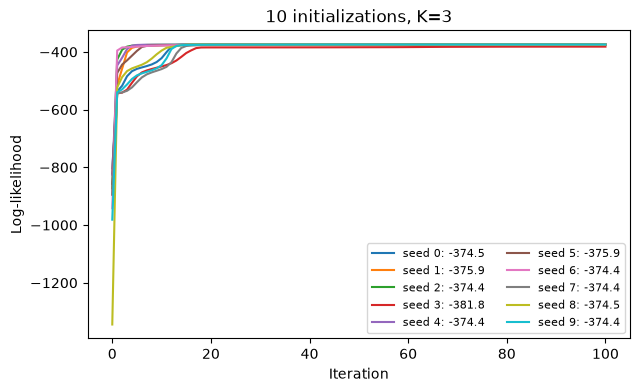

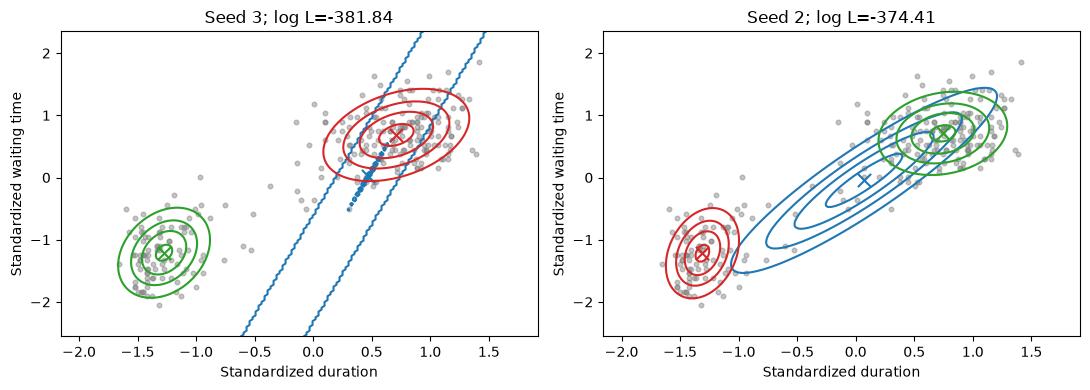

Minimum and maximum log L: [(3, np.float64(-381.839)), (2, np.float64(-374.411))]
Best seed (maximum log-likelihood): 2


In [7]:
K=3;Niter=100
runs={seed:EM_algorithm_v2(X,K,Niter,seed) for seed in range(10)}
fig,ax=plt.subplots(figsize=(7,4))
for seed,(history,_,_,_) in runs.items():ax.plot(history,label=f'seed {seed}: {history[-1]:.1f}')
ax.set(xlabel='Iteration',ylabel='Log-likelihood',title='10 initializations, K=3');ax.legend(ncol=2,fontsize=8);plt.show()
ranking=sorted(runs,key=lambda seed:runs[seed][0][-1]);selected=[ranking[0],ranking[-1]]
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,seed in zip(axes,selected):
    history,mu,cov,p=runs[seed]
    ax.scatter(*X.T,s=11,c='gray',alpha=.45)
    for k,color in enumerate(['tab:blue','tab:red','tab:green']):
        dens=ss.multivariate_normal.pdf(grid,mu[k],cov[k]).reshape(xx.shape)
        ax.contour(xx,yy,dens,levels=4,colors=color);ax.scatter(*mu[k],c=color,marker='x',s=90)
    ax.set(title=f'Seed {seed}; log L={history[-1]:.2f}',xlabel='Standardized duration',ylabel='Standardized waiting time')
fig.tight_layout();plt.show()
print('Minimum and maximum log L:',[(s,round(runs[s][0][-1],3)) for s in selected])
print('Best seed (maximum log-likelihood):',ranking[-1])

**Answer.** For K=3, seed 3 ends at a log-likelihood of −381.839, whereas seed 2 reaches −374.411: EM can get stuck in a local optimum. The plots also differ in where the components are placed, beyond simple color permutations. For a given K, we keep the solution with the highest log-likelihood, then compare the values of K with the BIC.


**Q7**. We now want to choose the optimal value of $K$. To do so, we would like to compare the likelihood of the models obtained with different values of $K$.

This can be done with a model selection criterion. In this lab we study the BIC:
$$ \text{BIC}(m) = k(m) \log(n) - 2 \log \mathcal{L}(m),$$
where $m$ is a model (here given by a value of $K$), $k(m)$ is the number of free parameters of the model, $n$ the number of samples, and $\mathcal{L}(m)$ the maximum of the likelihood of model $m$. The model with the lowest BIC is selected.

Show that $$k(m) = \frac{K}{2} (D+1)(D+2) - 1.$$

Compare the values of $K$ from 1 to 6. Which model is optimal according to the BIC?

K=1: parameters=5, best seed=0, log L=-544.99, BIC=1118.02


K=2: parameters=11, best seed=0, log L=-385.46, BIC=832.59


K=3: parameters=17, best seed=2, log L=-374.41, BIC=844.12


K=4: parameters=23, best seed=7, log L=-361.23, BIC=851.39


K=5: parameters=29, best seed=9, log L=-355.13, BIC=872.82


K=6: parameters=35, best seed=8, log L=-352.00, BIC=900.21


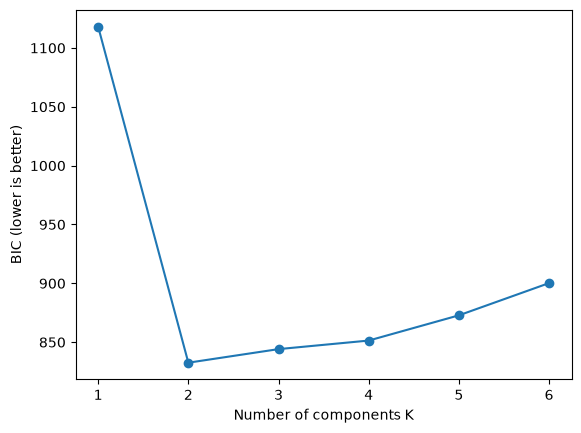

Selected K: 2


In [8]:
# Per component: D means + D(D+1)/2 terms of the symmetric covariance.
# Plus K-1 free weights: K*(D+1)*(D+2)/2 - 1.
D=X.shape[1];n=len(X);ks=np.arange(1,7)
bic_values=[];best_runs={}
for K in ks:
    candidates=[]
    for seed in range(10):
        try:candidates.append((EM_algorithm_v2(X,K,120,seed),seed))
        except RuntimeError:pass  # This initialization produced an empty component.
    if not candidates:raise RuntimeError(f'No solution for K={K}')
    (trace,mu,cov,p),seed=max(candidates,key=lambda item:item[0][0][-1])
    n_params=K*(D+1)*(D+2)//2-1
    bic=n_params*np.log(n)-2*trace[-1]
    bic_values.append(bic);best_runs[K]=(trace,mu,cov,p,seed)
    print(f'K={K}: parameters={n_params}, best seed={seed}, log L={trace[-1]:.2f}, BIC={bic:.2f}')
fig,ax=plt.subplots();ax.plot(ks,bic_values,'o-');ax.set(xticks=ks,xlabel='Number of components K',ylabel='BIC (lower is better)');plt.show()
print('Selected K:',int(ks[np.argmin(bic_values)]))

**Answer.** In dimension D, a component has D means and D(D+1)/2 independent covariance entries; the K weights summing to 1 add K−1 parameters. In total: K[D+D(D+1)/2]+K−1 = K(D+1)(D+2)/2−1. The lowest BIC is **832.59 for K=2**, ahead of 844.12 for K=3: the likelihood gain brought by a third component does not make up for its extra parameters.


**Bonus question**. Explain how the Gaussian mixture model can be used for clustering.

**Bonus answer.** Each observation receives the posterior probabilities `responsibility[i,k]` of belonging to each of the K groups. These probabilities give a soft clustering, or the observation can be assigned to the most probable component (`argmax`). The group index itself has no intrinsic meaning.